FIRST 5 ROWS
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN 

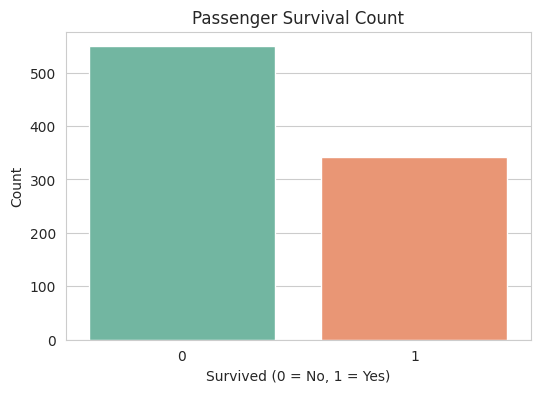

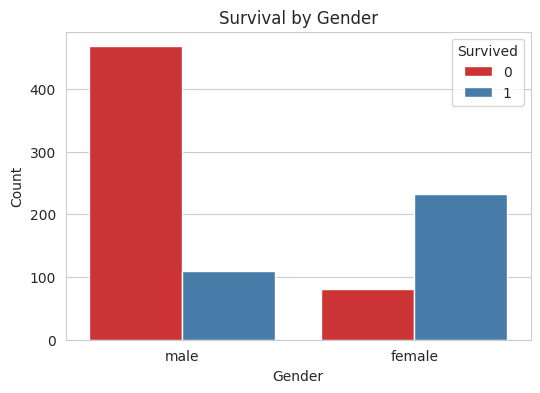

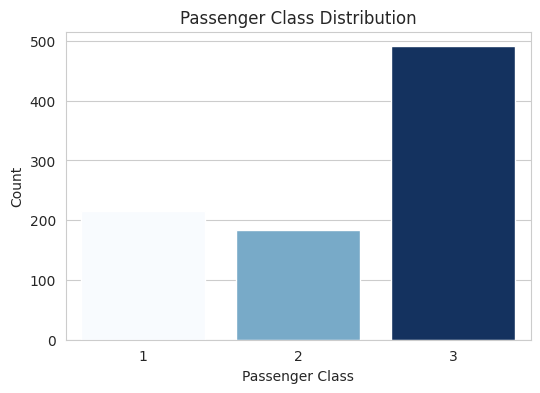

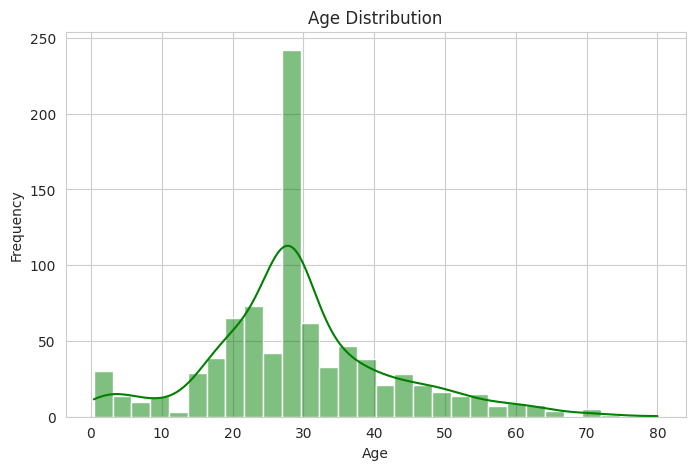

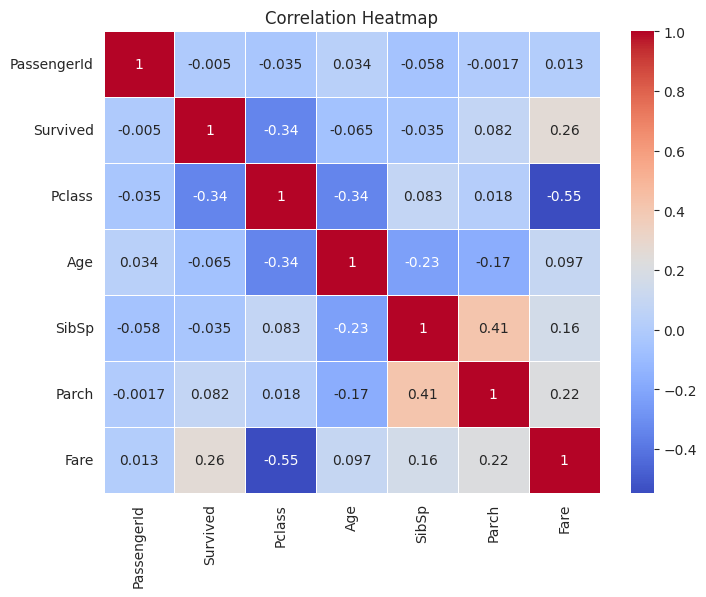


SUMMARY STATISTICS

Average Age
29.36158249158249

Average Fare
32.204207968574636

Passenger Survival Count
Survived
0    549
1    342
Name: count, dtype: int64

Passenger Class Distribution
Pclass
3    491
1    216
2    184
Name: count, dtype: int64

Gender Distribution
Sex
male      577
female    314
Name: count, dtype: int64

Average Fare by Passenger Class
Pclass
1    84.154687
2    20.662183
3    13.675550
Name: Fare, dtype: float64

Average Age by Gender
Sex
female    27.929936
male      30.140676
Name: Age, dtype: float64

Survival Rate by Gender
Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

Survival Rate by Passenger Class
Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

Cleaned dataset saved successfully as
'cleaned_titanic_hypothesis.csv'

All graphs have been saved successfully.

TASK COMPLETED SUCCESSFULLY


In [1]:
# ==========================================================
# TASK 3
# Statistical Analysis and Hypothesis Testing Using Python
# Titanic Dataset
# ==========================================================

# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

# Set Visualization Style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

# ==========================================================
# LOAD DATASET
# ==========================================================

df = pd.read_csv("train.csv")

print("="*60)
print("FIRST 5 ROWS")
print("="*60)
print(df.head())

print("\nDataset Shape:", df.shape)

print("\nDataset Information")
print(df.info())

print("\nMissing Values")
print(df.isnull().sum())

# ==========================================================
# DATA CLEANING
# ==========================================================

# Fill Missing Values
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Drop Cabin Column
df.drop(columns=["Cabin"], inplace=True)

# Remove Duplicate Rows
df.drop_duplicates(inplace=True)

print("\nMissing Values After Cleaning")
print(df.isnull().sum())

# ==========================================================
# HYPOTHESIS
# ==========================================================

print("\n" + "="*60)
print("HYPOTHESIS")
print("="*60)

print("Null Hypothesis (H0):")
print("There is NO significant association between Gender and Survival.")

print("\nAlternative Hypothesis (H1):")
print("There IS a significant association between Gender and Survival.")

# ==========================================================
# CHI-SQUARE TEST
# ==========================================================

print("\n" + "="*60)
print("CHI-SQUARE TEST")
print("="*60)

contingency_table = pd.crosstab(df["Sex"], df["Survived"])

print("\nContingency Table")
print(contingency_table)

chi2, p, dof, expected = chi2_contingency(contingency_table)

print("\nChi-Square Statistic :", chi2)
print("Degrees of Freedom :", dof)
print("P-value :", p)

print("\nExpected Frequencies")
print(expected)

alpha = 0.05

print("\nDecision")

if p < alpha:
    print("Reject the Null Hypothesis")
    print("Conclusion: Gender and Survival are significantly associated.")
else:
    print("Fail to Reject the Null Hypothesis")
    print("Conclusion: No significant association exists.")

# ==========================================================
# VISUALIZATION 1
# SURVIVAL COUNT
# ==========================================================

plt.figure(figsize=(6,4))
sns.countplot(data=df, x="Survived", hue="Survived",
              palette="Set2", legend=False)

plt.title("Passenger Survival Count")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Count")

plt.savefig("graph1_survival_count.png")
plt.show()

# ==========================================================
# VISUALIZATION 2
# SURVIVAL BY GENDER
# ==========================================================

plt.figure(figsize=(6,4))
sns.countplot(data=df,
              x="Sex",
              hue="Survived",
              palette="Set1")

plt.title("Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")

plt.savefig("graph2_survival_gender.png")
plt.show()

# ==========================================================
# VISUALIZATION 3
# PASSENGER CLASS
# ==========================================================

plt.figure(figsize=(6,4))
sns.countplot(data=df,
              x="Pclass",
              hue="Pclass",
              palette="Blues",
              legend=False)

plt.title("Passenger Class Distribution")
plt.xlabel("Passenger Class")
plt.ylabel("Count")

plt.savefig("graph3_passenger_class.png")
plt.show()

# ==========================================================
# VISUALIZATION 4
# AGE DISTRIBUTION
# ==========================================================

plt.figure(figsize=(8,5))
sns.histplot(df["Age"],
             bins=30,
             kde=True,
             color="green")

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.savefig("graph4_age_distribution.png")
plt.show()

# ==========================================================
# VISUALIZATION 5
# CORRELATION HEATMAP
# ==========================================================

numeric_df = df.select_dtypes(include=["number"])

plt.figure(figsize=(8,6))

sns.heatmap(numeric_df.corr(),
            annot=True,
            cmap="coolwarm",
            linewidths=0.5)

plt.title("Correlation Heatmap")

plt.savefig("graph5_heatmap.png")
plt.show()

# ==========================================================
# SUMMARY STATISTICS
# ==========================================================

print("\n" + "="*60)
print("SUMMARY STATISTICS")
print("="*60)

print("\nAverage Age")
print(df["Age"].mean())

print("\nAverage Fare")
print(df["Fare"].mean())

print("\nPassenger Survival Count")
print(df["Survived"].value_counts())

print("\nPassenger Class Distribution")
print(df["Pclass"].value_counts())

print("\nGender Distribution")
print(df["Sex"].value_counts())

print("\nAverage Fare by Passenger Class")
print(df.groupby("Pclass")["Fare"].mean())

print("\nAverage Age by Gender")
print(df.groupby("Sex")["Age"].mean())

print("\nSurvival Rate by Gender")
print(df.groupby("Sex")["Survived"].mean())

print("\nSurvival Rate by Passenger Class")
print(df.groupby("Pclass")["Survived"].mean())

# ==========================================================
# SAVE CLEANED DATASET
# ==========================================================

df.to_csv("cleaned_titanic_hypothesis.csv", index=False)

print("\nCleaned dataset saved successfully as")
print("'cleaned_titanic_hypothesis.csv'")

print("\nAll graphs have been saved successfully.")

print("\n" + "="*60)
print("TASK COMPLETED SUCCESSFULLY")
print("="*60)